In [ ]:
!pip install rank_bm25

In [ ]:
import os
os.environ["WANDB_MODE"] = "disabled"
from sentence_transformers.cross_encoder.evaluation import CEBinaryClassificationEvaluator


Loaded 13756 examples
Train=12380, Val=1376


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

/tmp/ipython-input-2899703397.py:113: DeprecationWarning: This evaluator has been deprecated in favor of the more general CrossEncoderClassificationEvaluator. Please use CrossEncoderClassificationEvaluator instead, which supports both binary and multi-class evaluation. It accepts approximately the same inputs as this evaluator.
  val_evaluator = CEBinaryClassificationEvaluator(



===== STARTING TRAINING =====
Epoch 1/3 — Train Loss: 0.4656 | Val Loss: 0.4619
✓ Saved new best checkpoint.
Epoch 2/3 — Train Loss: 0.4051 | Val Loss: 0.4034
✓ Saved new best checkpoint.
Epoch 3/3 — Train Loss: 0.3374 | Val Loss: 0.4143
Training complete!


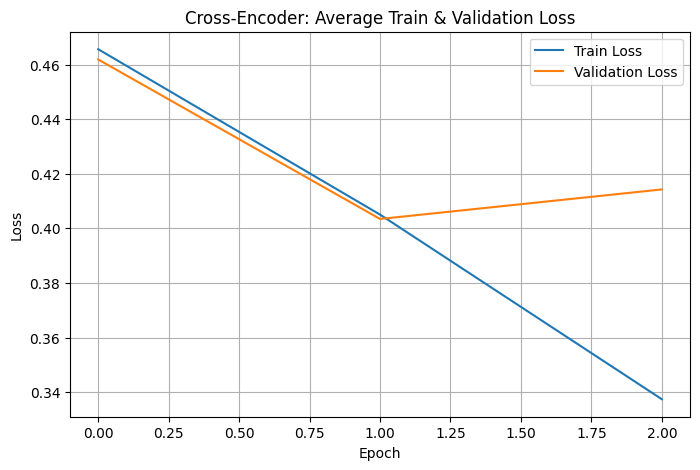

Saved learning curve to loss_curves_avg.png

===== RETRIEVAL RECALL =====
Recall@5: 1.0000
Recall@10: 1.0000
Recall@20: 1.0000


In [ ]:
import json
import logging
import matplotlib.pyplot as plt
from sentence_transformers import InputExample, CrossEncoder, LoggingHandler
from torch.utils.data import DataLoader
from sklearn.model_selection import GroupShuffleSplit
from sentence_transformers.cross_encoder.evaluation import CEBinaryClassificationEvaluator
import torch
import torch.nn.functional as F
import numpy as np

logging.basicConfig(format='%(asctime)s - %(message)s',
                    level=logging.INFO,
                    handlers=[LoggingHandler()])

def load_finder_triplets(path):
    examples = []
    with open(path, "r") as f:
        for line in f:
            item = json.loads(line)

            query = item["query"]
            pos = item["positive"]["text"]

            examples.append(InputExample(texts=[query, pos], label=1))

            for neg in item["negatives"]:
                examples.append(InputExample(
                    texts=[query, neg["text"]],
                    label=0
                ))
    return examples


data_path = "finder_triplets_optimized.jsonl"
examples = load_finder_triplets(data_path)
print(f"Loaded {len(examples)} examples")


queries = [ex.texts[0] for ex in examples]

splitter = GroupShuffleSplit(test_size=0.1, n_splits=1, random_state=42)
train_idx, val_idx = next(splitter.split(examples, groups=queries))

train_samples = [examples[i] for i in train_idx]
val_samples = [examples[i] for i in val_idx]

print(f"Train={len(train_samples)}, Val={len(val_samples)}")


model = CrossEncoder(
    model_name="bert-base-uncased",
    num_labels=1,
    max_length=512
)

device = model.device

# Custom collate function for DataLoader
def custom_collate_fn(batch_examples):
    queries = [ex.texts[0] for ex in batch_examples]
    passages = [ex.texts[1] for ex in batch_examples]
    labels = torch.tensor([ex.label for ex in batch_examples], dtype=torch.float)

    # Tokenize the pairs using the CrossEncoder's tokenizer
    tokenized = model.tokenizer(
        queries,
        passages,
        padding=True,
        truncation='longest_first',
        max_length=model.max_length,
        return_tensors="pt"
    )

    return tokenized, labels

train_dataloader = DataLoader(train_samples, shuffle=True, batch_size=8, collate_fn=custom_collate_fn)
val_dataloader = DataLoader(val_samples, shuffle=False, batch_size=8, collate_fn=custom_collate_fn)


def compute_val_loss(model, dataloader):
    model.model.eval()
    losses = []

    with torch.no_grad():
        for features, labels in dataloader:
            features = {k: v.to(device) for k, v in features.items()}
            labels = labels.float().to(device)
            logits = model.model(**features).logits.squeeze(-1)
            loss = F.binary_cross_entropy_with_logits(logits, labels)
            losses.append(loss.item())

    return float(sum(losses) / len(losses))



val_evaluator = CEBinaryClassificationEvaluator(
    sentence_pairs=[ex.texts for ex in val_samples],
    labels=[float(ex.label) for ex in val_samples],
    name="finder-classification"
)

optimizer = torch.optim.AdamW(model.model.parameters(), lr=2e-5)

num_epochs = 3
best_val_loss = float("inf")
train_epoch_losses = []
val_epoch_losses = []


for epoch in range(num_epochs):
    model.model.train()

    total_loss = 0
    batch_count = 0

    for features, labels in train_dataloader:
        # Move features to the same device as the model
        features = {k: v.to(device) for k, v in features.items()}
        labels = labels.float().to(device)

        optimizer.zero_grad()
        logits = model.model(**features).logits.squeeze(-1)
        loss = F.binary_cross_entropy_with_logits(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        batch_count += 1

    avg_train_loss = total_loss / batch_count
    train_epoch_losses.append(avg_train_loss)

    avg_val_loss = compute_val_loss(model, val_dataloader)
    val_epoch_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} — Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # Save best checkpoint
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        model.save("cross_encoder_finder_best")
        print("✓ Saved new best checkpoint.")


# Final classification metrics
val_evaluator(model)

print("Training complete!")


plt.figure(figsize=(8, 5))
plt.plot(train_epoch_losses, label="Train Loss")
plt.plot(val_epoch_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Cross-Encoder: Average Train & Validation Loss")
plt.legend()
plt.grid()
plt.savefig("loss_curves_avg.png")
plt.show()

print("Saved learning curve to loss_curves_avg.png")


def compute_recall_at_k(model, examples, k_list=[5, 10, 20]):
    grouped = {}


    for ex in examples:
        q = ex.texts[0]
        if q not in grouped:
            grouped[q] = []
        grouped[q].append((ex.texts[1], ex.label))

    recalls = {k: [] for k in k_list}

    for q, pairs in grouped.items():
        passages, labels = zip(*pairs)
        scores = model.predict([[q, p] for p in passages])

        ranked = sorted(zip(passages, labels, scores), key=lambda x: -x[2])
        ranked_labels = [lbl for _, lbl, _ in ranked]

        for k in k_list:
            recalls[k].append(1 if 1 in ranked_labels[:k] else 0)

    return {k: float(np.mean(v)) for k, v in recalls.items()}


best_model = CrossEncoder("cross_encoder_finder_best")
recall_scores = compute_recall_at_k(best_model, val_samples)

print("\n===== RETRIEVAL RECALL =====")
for k, v in recall_scores.items():
    print(f"Recall@{k}: {v:.4f}")